In [4]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

# 03 — The MeltPool Object: Dimensions & Lazy Evaluation

The `MeltPool` is the central physics hub. It accepts a `Material` and `ProcessParameters` and exposes `length`, `width`, and `depth` as properties. Solvers run **lazily** — only when you first access a dimension — and are **cached** for all subsequent calls.

## Section 1 — Single-point melt pool

In [5]:
from lpbf_maps.materials import Material
from lpbf_maps.parameters import ProcessParameters
from lpbf_maps.meltpool import MeltPool

material = Material.from_library("NiTi_Sheikh")
params = ProcessParameters(laser_power=200.0, scan_speed=1.0, beam_radius=50e-6)

pool = MeltPool(material, params)
print("Pool created. Physics hasn't run yet.")

# Now we access a dimension
print(f"Length: {float(pool.length) * 1e6:.2f} µm")
print(f"Width: {float(pool.width) * 1e6:.2f} µm")
print(f"Depth: {float(pool.depth) * 1e6:.2f} µm")

print("Second access is cached!")
print(f"Depth again: {float(pool.depth) * 1e6:.2f} µm")

Pool created. Physics hasn't run yet.
Length: 496.75 µm
Width: 169.77 µm
Depth: 64.50 µm
Second access is cached!
Depth again: 64.50 µm


## Section 2 — Vectorized melt pool (1D scan speed sweep)

In [6]:
import numpy as np

ti64 = Material.from_library("Ti64")
scan_speeds = np.linspace(0.4, 2.0, 12)
params_1d = ProcessParameters(laser_power=250.0, scan_speed=scan_speeds, beam_radius=40e-6)

pool_1d = MeltPool(ti64, params_1d)

print("Widths (µm):")
print(pool_1d.width * 1e6)
print(f"Depth shape: {pool_1d.depth.shape}")

Widths (µm):
[251.07600159 221.18525346 200.66772053 185.69133279 174.02439226
 164.86345689 157.34000966 151.1371768  146.26463942 142.17906864
 138.9604952  135.91718298]
Depth shape: (12,)


## Section 3 — 2D evaluation grid

In [7]:
laser_powers = np.array([100, 150, 200, 250, 300])[:, np.newaxis]
scan_speeds_2d = np.array([0.5, 1.0, 1.5, 2.0])[np.newaxis, :]
params_2d = ProcessParameters(laser_power=laser_powers, scan_speed=scan_speeds_2d, beam_radius=50e-6)

pool_2d = MeltPool(ti64, params_2d)
print(f"Length shape: {pool_2d.length.shape}")

print("\nDepths (µm):")
for i in range(5):
    row = []
    for j in range(4):
        row.append(f"{pool_2d.depth[i, j] * 1e6:6.1f}")
    print(" ".join(row))

Length shape: (5, 4)

Depths (µm):
  52.7   35.3   26.6   21.2
  73.4   50.6   39.4   32.4
  89.9   62.7   49.4   41.2
 104.1   72.8   57.9   48.6
 116.6   81.8   65.3   55.1


## Section 4 — The `get_material_property()` method on PrintabilitySpace

In [8]:
from lpbf_maps.printability import PrintabilitySpace
from lpbf_maps.defects import DefectSuite

suite = DefectSuite()
space = PrintabilitySpace(pool_2d, suite)

print(f"Melting Temp: {space.get_material_property('melting_temperature')} K")
print(f"Thermal Diffusivity: {space.get_material_property('thermal_diffusivity')} m^2/s")

try:
    space.get_material_property("nonexistent")
except ValueError as e:
    print(f"Caught ValueError: {e}")

Melting Temp: 1877.0 K
Thermal Diffusivity: 1.2001579155151994e-05 m^2/s
Caught ValueError: Property 'nonexistent' not found in Material.


## Section 5 — The `len()` method on PrintabilitySpace

Standard `len()` fails on 0-D NumPy arrays. `PrintabilitySpace.len()` safely handles scalar vs array grids.

In [9]:
print(f"Len of scan_speed: {space.len('scan_speed')}")
print(f"Len of laser_power: {space.len('laser_power')}")

# Test with a scalar
scalar_pool = MeltPool(ti64, ProcessParameters(laser_power=200, scan_speed=1.0, beam_radius=50e-6))
scalar_space = PrintabilitySpace(scalar_pool, suite)
print(f"Len of scalar scan_speed: {scalar_space.len('scan_speed')}")

Len of scan_speed: 1
Len of laser_power: 5
Len of scalar scan_speed: 1


## Section 6 — Normalized Enthalpy (Keyhole Criterion)

The `MeltPool` object automatically computes King's normalized enthalpy for the given parameters using the formula: $(A \cdot P) / (\pi \cdot \rho \cdot C_p \cdot T_m \cdot \sqrt{\alpha \cdot v \cdot r^3})$.

In [10]:
print("Normalized Enthalpy for scalar pool:")
print(f"{scalar_pool.normalized_enthalpy:.2f}")

print("\nNormalized Enthalpy array shape for 2D sweep:")
print(pool_2d.normalized_enthalpy.shape)
print(pool_2d.normalized_enthalpy)

Normalized Enthalpy for scalar pool:
5.25

Normalized Enthalpy array shape for 2D sweep:
(5, 4)
[[ 3.71050223  2.62372129  2.14225946  1.85525111]
 [ 5.56575334  3.93558193  3.21338919  2.78287667]
 [ 7.42100446  5.24744257  4.28451892  3.71050223]
 [ 9.27625557  6.55930322  5.35564865  4.63812778]
 [11.13150668  7.87116386  6.42677838  5.56575334]]


## Section 7 — Plotting Dimension Sweeps

You can visualize how melt pool dimensions evolve over a single parameter axis using `.plot_dimensions(sweep_axis)`. This requires the `MeltPool` to have an exactly 1D parameter sweep.

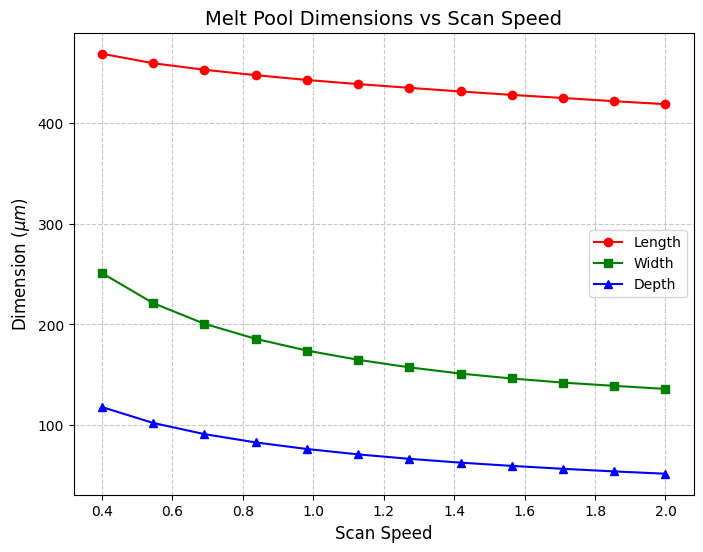

In [11]:
fig, ax = pool_1d.plot_dimensions('scan_speed')
# This plots Length, Width, and Depth against the scan_speed array from Section 2.

## Section 8 — 2D Dimension Contour Maps

For 2D parameter sweeps, you can use `.plot_dimensions_2d(x_axis, y_axis)` to render detailed contour maps of Length, Width, and Depth.

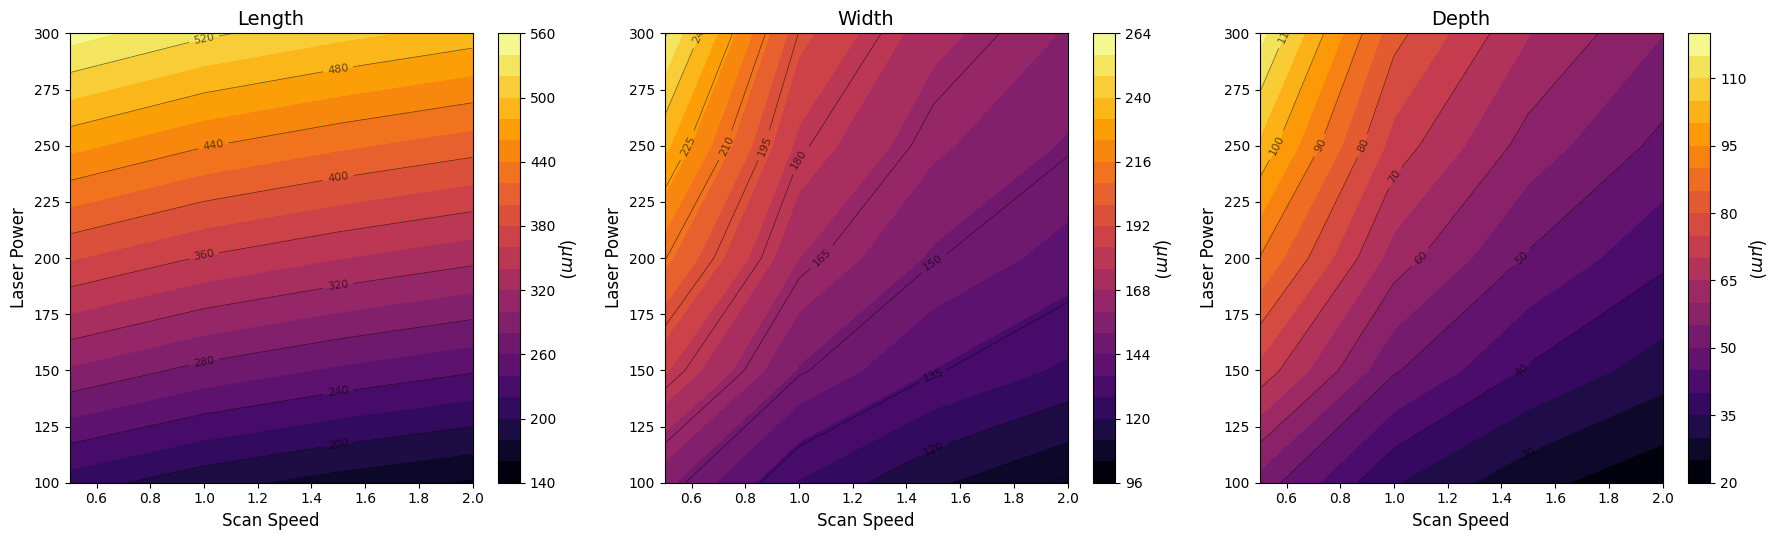

In [12]:
fig, axes = pool_2d.plot_dimensions_2d('scan_speed', 'laser_power')